In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [2]:
df = pd.read_csv('water_potability.csv')
df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


In [3]:
stats = df.describe()
stats

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


Απαντάμε στο πρώτο ερώτημα από μια πρώτη ματιά λείπουν δεδομένα παρακάτω αναλύω επακριβώς ποια είναι και πως τα διαχειρίστηκα, τα δεδομένα είναι φυσιολογικά θα τα έλεγα αρκετά καλά παρά τις ελλείψεις. Θα φανούν επιπλέον πράγματα από τα διαγράμματα.

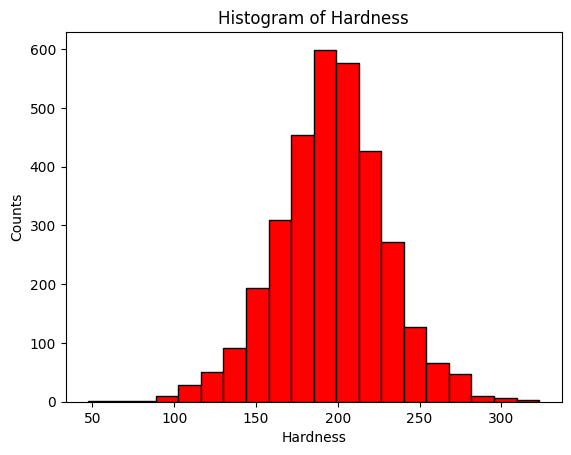

In [4]:
plt.title('Histogram of Hardness')
plt.hist(df['Hardness'], bins=20, color = 'red', edgecolor='black')
plt.xlabel('Hardness')
plt.ylabel('Counts')
plt.show()

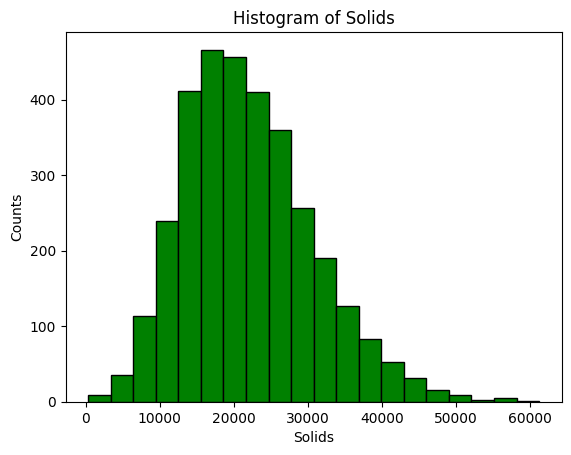

In [5]:
plt.title('Histogram of Solids')
plt.hist(df['Solids'], bins=20, color = 'green', edgecolor='black')
plt.xlabel('Solids')
plt.ylabel('Counts')
plt.show()


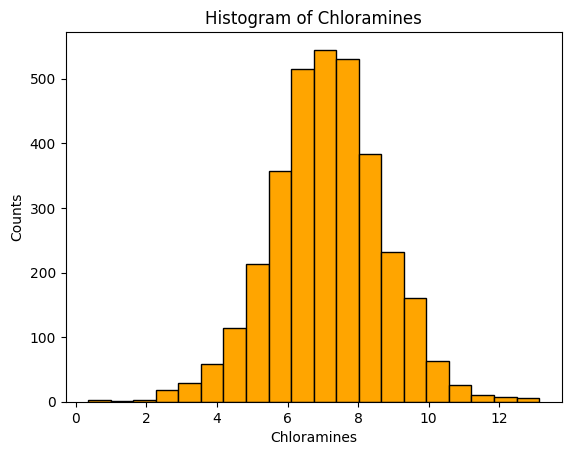

In [6]:
plt.title('Histogram of Chloramines')
plt.hist(df['Chloramines'], bins=20, color = 'orange', edgecolor='black')
plt.xlabel('Chloramines')
plt.ylabel('Counts')
plt.show()

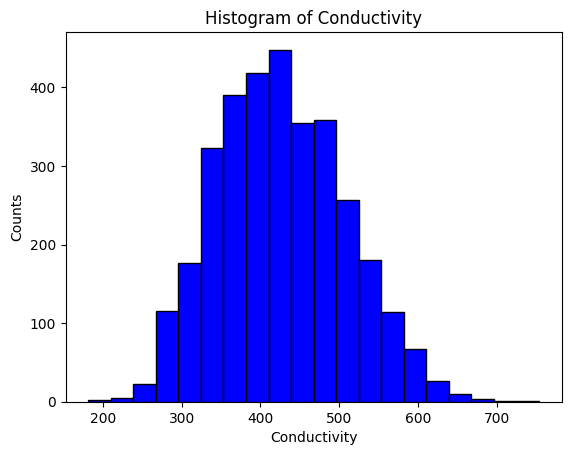

In [7]:
plt.title('Histogram of Conductivity')
plt.hist(df['Conductivity'], bins=20, color = 'blue', edgecolor='black')
plt.xlabel('Conductivity')
plt.ylabel('Counts')
plt.show()

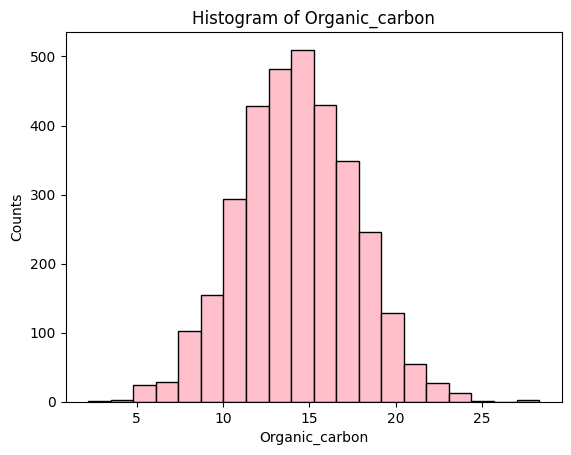

In [8]:
plt.title('Histogram of Organic_carbon')
plt.hist(df['Organic_carbon'], bins=20, color = 'pink', edgecolor='black')
plt.xlabel('Organic_carbon')
plt.ylabel('Counts')
plt.show()

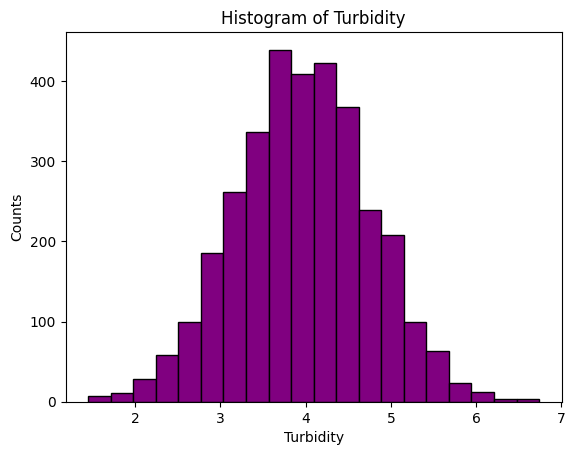

In [9]:
plt.title('Histogram of Turbidity')
plt.hist(df['Turbidity'], bins=20, color = 'purple', edgecolor='black')
plt.xlabel('Turbidity')
plt.ylabel('Counts')
plt.show()

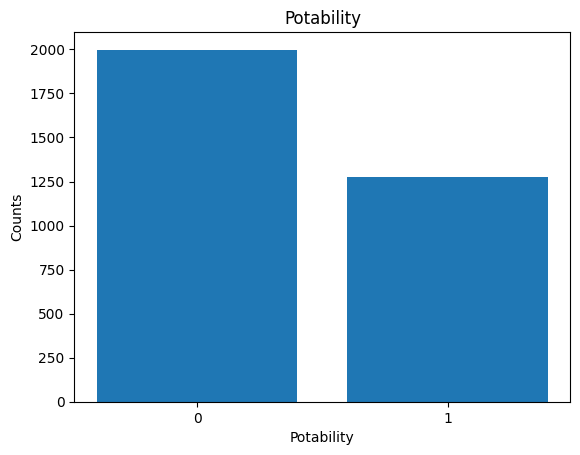

Potability
0    60.989011
1    39.010989
Name: count, dtype: float64


In [10]:
count_outcome = df['Potability'].value_counts()
labels = count_outcome.index
values = count_outcome.values
plt.title('Potability')
plt.bar(labels, values)
plt.xlabel('Potability')
plt.ylabel('Counts')
plt.xticks(labels)
plt.show()
print((count_outcome) * 100/ count_outcome.sum())

Παρακάτω κάνω μια ανάλυση στα δεδομένα που λείπουν και απαντάω και το ερώτημα 4 γενικά οι κατανωμές ήταν πολύ κοντά σε κανονική κατανομή άρα απλά fill.mean αρκούσαν αλλά έβαλα median στην περίπτωση του sulfate κυρίως λόγο του μεγάλου ποσοστού έλλειψης δεδομένων.

In [11]:
print(df[df.isna().any(axis=1)])

            ph    Hardness        Solids  Chloramines     Sulfate  \
0          NaN  204.890455  20791.318981     7.300212  368.516441   
1     3.716080  129.422921  18630.057858     6.635246         NaN   
2     8.099124  224.236259  19909.541732     9.275884         NaN   
8          NaN  118.988579  14285.583854     7.804174  268.646941   
11    7.974522  218.693300  18767.656682     8.110385         NaN   
...        ...         ...           ...          ...         ...   
3266  8.372910  169.087052  14622.745494     7.547984         NaN   
3272  7.808856  193.553212  17329.802160     8.061362         NaN   
3273  9.419510  175.762646  33155.578218     7.350233         NaN   
3274  5.126763  230.603758  11983.869376     6.303357         NaN   
3275  7.874671  195.102299  17404.177061     7.509306         NaN   

      Conductivity  Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       564.308654       10.379783        86.990970   2.963135           0  
1       592.88535

In [12]:
missing_percent = df.isna().mean() * 100
print(missing_percent)


ph                 14.987790
Hardness            0.000000
Solids              0.000000
Chloramines         0.000000
Sulfate            23.840049
Conductivity        0.000000
Organic_carbon      0.000000
Trihalomethanes     4.945055
Turbidity           0.000000
Potability          0.000000
dtype: float64


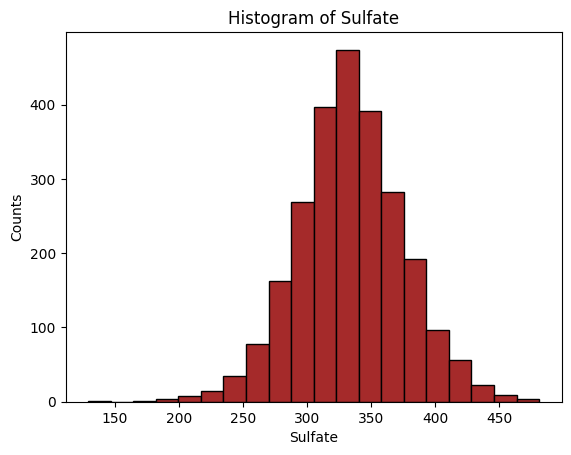

-0.03594662160706187
0.6482628149948058


In [13]:
plt.title('Histogram of Sulfate')
plt.hist(df['Sulfate'], bins = 20, color = "brown", edgecolor = "black")
plt.xlabel('Sulfate')
plt.ylabel('Counts')
plt.show()
print(df['Sulfate'].skew())
print(df['Sulfate'].kurtosis())


In [14]:
median_sulfate = df['Sulfate'].median()
df['Sulfate'] = df['Sulfate'].fillna(median_sulfate)



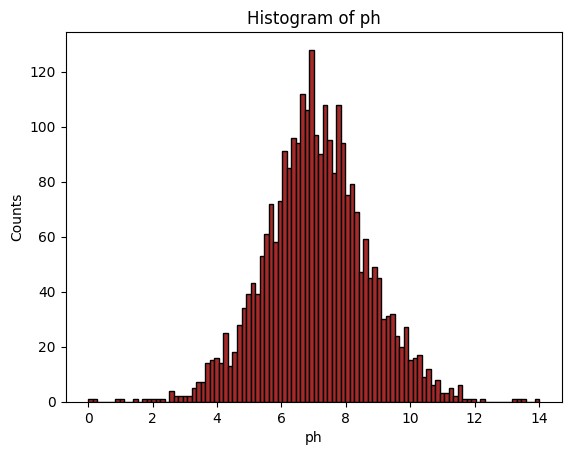

In [15]:
plt.title('Histogram of ph')
plt.hist(df['ph'], bins = 100, color = "brown", edgecolor = "black")
plt.xlabel('ph')
plt.ylabel('Counts')
plt.show()

In [16]:
mean_ph = df['ph'].mean()
df['ph'] = df['ph'].fillna(mean_ph)

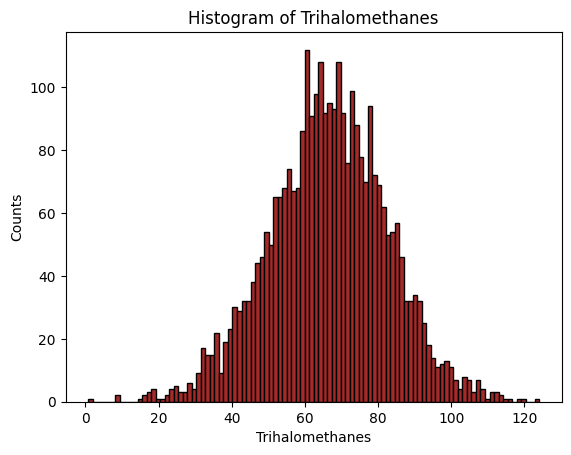

-0.08303067407901553
0.2385974402088653


In [17]:
plt.title('Histogram of Trihalomethanes')
plt.hist(df['Trihalomethanes'], bins = 100, color = "brown", edgecolor = "black")
plt.xlabel('Trihalomethanes')
plt.ylabel('Counts')
plt.show()
print(df['Trihalomethanes'].skew())
print(df['Trihalomethanes'].kurtosis())

In [18]:
mean_Trihalomethanes = df['Trihalomethanes'].mean()
df['Trihalomethanes'] = df['Trihalomethanes'].fillna(mean_Trihalomethanes)

Εδώ το ερώτημα 2 δίνει λογικά αποτελέσματα επαληθεύεται η ιδιότητα του ΠΟΥ και έχω την υποψία ότι το ph θα είναι ίσως από τα σημαντικότερα χαρακτηριστικά κρίσης του νερού στο δείγμα μας και γενικότερα.

In [19]:
percentage_below_6_5 = (df['ph'] < 6.5).mean() * 100
print(f"Ποσοστό pH: {percentage_below_6_5:.2f}%")

Ποσοστό pH: 29.55%


In [20]:
percentage_above_8_5 = (df['ph'] > 8.5).mean() * 100
print(f"Ποσοστό pH: {percentage_above_8_5:.2f}%")

Ποσοστό pH: 14.93%


In [21]:
percentage_below_8_5_n_under_6_5 = ((df['ph'] <= 8.5) & (df['ph']>= 6.5)).mean() * 100
print(f"Ποσοστά pH: {percentage_below_8_5_n_under_6_5:.2f}%")


Ποσοστά pH: 55.53%


Ερώτημα 3 παρατηρούμε μεγάλη επικάλυψη άρα τα 2 αυτά features δεν θα αρκούσαν για πρόβλεψη σχετικά με τον ΠΟΥ και την πρόταση <= 4 Χλωραμίνη πιστεύω ότι υπάρχει σύνδεση features αλλά από μόνη της η Χλωραμίνη δεν μας λέει ξεκάθαρα την Ποσιμότητα του νερού.

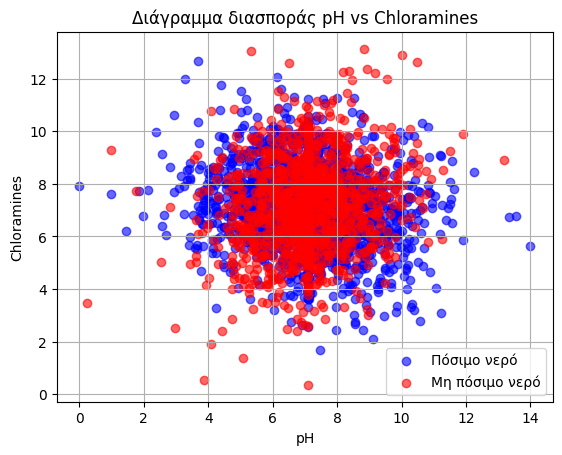

In [22]:

plt.scatter(
    df[df['Potability'] == 0]['ph'],
    df[df['Potability'] == 0]['Chloramines'],
    color='blue', label='Πόσιμο νερό', alpha=0.6
)


plt.scatter(
    df[df['Potability'] == 1]['ph'],
    df[df['Potability'] == 1]['Chloramines'],
    color='red', label='Μη πόσιμο νερό', alpha=0.6
)

plt.xlabel('pH')
plt.ylabel('Chloramines')
plt.title('Διάγραμμα διασποράς pH vs Chloramines')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
input_df = df.drop(columns=['Potability'])
targets_df = df['Potability']

x = np.array(input_df)
y = np.array(targets_df)
x.shape, y.shape

((3276, 9), (3276,))

In [24]:
seed = 0
test_size = 0.3

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=seed)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((2293, 9), (2293,), (983, 9), (983,))

In [25]:
# Ένα απλό μοντέλο πριν το ερώτημα 7 θα κρατήσω το καλύτερο στη συνέχεια αλλά πιθανόν να είναι το καλύτερο δεν δομίζω ότι θα βελτιωθεί
tree = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features=None,
    ccp_alpha=0,
    random_state=seed
)


tree.fit(x_train, y_train)


train_acc = tree.score(x_train, y_train)
test_acc = tree.score(x_test, y_test)


print(f"Train accuracy: {train_acc:.3f}")
print(f"Test accuracy:  {test_acc:.3f}")

Train accuracy: 0.671
Test accuracy:  0.655


In [26]:
# Δεν φαίνεται πολύ σίγουρο το μοντέλο μας ας δοκιμάσουμε το ερώτημα 7
y_predict = tree.predict_proba(x_test)
y_predict

array([[0.64637858, 0.35362142],
       [0.64637858, 0.35362142],
       [0.64637858, 0.35362142],
       ...,
       [0.64637858, 0.35362142],
       [0.64637858, 0.35362142],
       [1.        , 0.        ]])

In [27]:
#Κανείς συνδιασμός δεν είναι αρκετά ικανοποιητικός
results = []

criteria = ['gini', 'entropy']
max_depths = [None, 3, 5]
min_splits = [2, 5]
min_leafs = [1, 2]
max_feats = [None, 'sqrt']
ccp_alphas = [0, 0.01]

for crit in criteria:
    for md in max_depths:
        for msp in min_splits:
            for msl in min_leafs:
                for mf in max_feats:
                    for ccp in ccp_alphas:
                        tree = DecisionTreeClassifier(
                            criterion=crit,
                            max_depth=md,
                            min_samples_split=msp,
                            min_samples_leaf=msl,
                            max_features=mf,
                            ccp_alpha=ccp,
                            random_state=seed,
                        )
                        tree.fit(x_train, y_train)

                        train_acc = tree.score(x_train, y_train)
                        test_acc = tree.score(x_test, y_test)

                        results.append({
                            'criterion': crit,
                            'max_depth': md,
                            'min_samples_split': msp,
                            'min_samples_leaf': msl,
                            'max_features': mf,
                            'ccp_alpha': ccp,
                            'train_acc': train_acc,
                            'test_acc': test_acc,
                        })


results_df = pd.DataFrame(results)
print(results_df)

   criterion  max_depth  min_samples_split  min_samples_leaf max_features  \
0       gini        NaN                  2                 1         None   
1       gini        NaN                  2                 1         None   
2       gini        NaN                  2                 1         sqrt   
3       gini        NaN                  2                 1         sqrt   
4       gini        NaN                  2                 2         None   
..       ...        ...                ...               ...          ...   
91   entropy        5.0                  5                 1         sqrt   
92   entropy        5.0                  5                 2         None   
93   entropy        5.0                  5                 2         None   
94   entropy        5.0                  5                 2         sqrt   
95   entropy        5.0                  5                 2         sqrt   

    ccp_alpha  train_acc  test_acc  
0        0.00   1.000000  0.574771  
1

In [28]:
depth3_df = results_df[results_df['max_depth'] == 3]

best_depth3 = depth3_df.sort_values('test_acc', ascending=False).iloc[0]
print(best_depth3)

criterion             entropy
max_depth                 3.0
min_samples_split           5
min_samples_leaf            1
max_features             None
ccp_alpha                 0.0
train_acc            0.641082
test_acc             0.639878
Name: 72, dtype: object


In [29]:
best_tree = DecisionTreeClassifier(
    criterion=best_depth3['criterion'],
    max_depth=int(best_depth3['max_depth']),
    min_samples_split=best_depth3['min_samples_split'],
    min_samples_leaf=best_depth3['min_samples_leaf'],
    max_features=best_depth3['max_features'],
    ccp_alpha=best_depth3['ccp_alpha'],
    random_state=seed
)

best_tree.fit(x_train, y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0), criterion='entropy',
                       max_depth=3, min_samples_leaf=np.int64(1),
                       min_samples_split=np.int64(5), random_state=0)

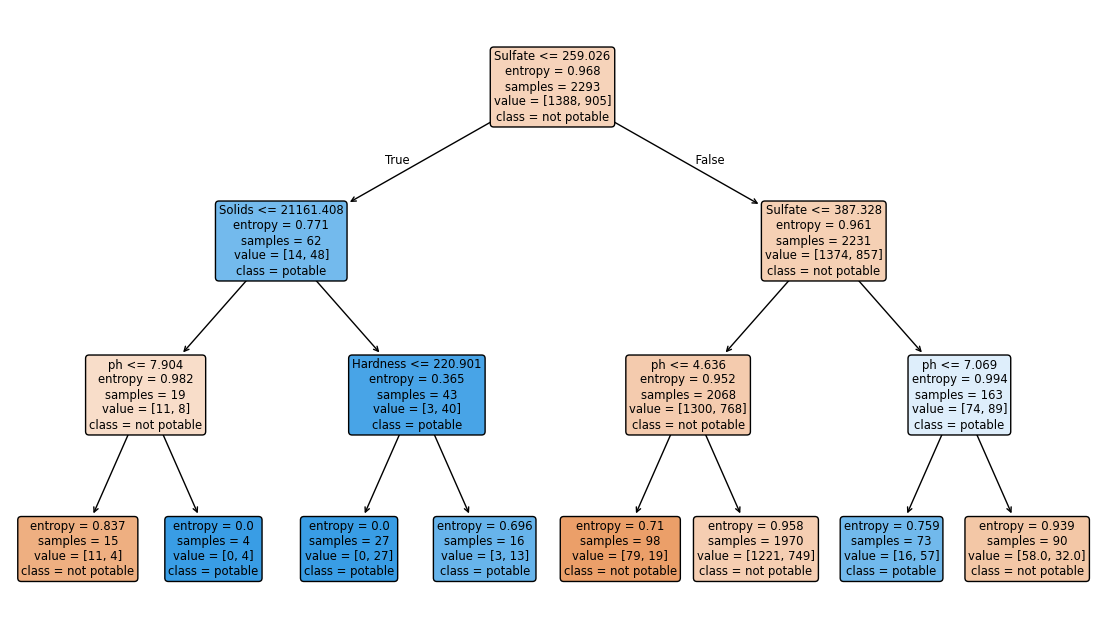

In [30]:

plt.figure(figsize=(14,8))
plot_tree(
    best_tree,
    feature_names=input_df.columns,
    class_names=['not potable', 'potable'],
    filled=True,
    rounded=True
)
plt.show()

In [31]:
#Επιβεβαιώνεται η αρχική μου υπόθεση
best_row = results_df.sort_values('test_acc', ascending=False).iloc[0]
print(best_row)


criterion             entropy
max_depth                 5.0
min_samples_split           5
min_samples_leaf            2
max_features             None
ccp_alpha                 0.0
train_acc            0.671173
test_acc             0.655137
Name: 92, dtype: object


In [32]:
best_tree = DecisionTreeClassifier(
    criterion=best_row['criterion'],
    max_depth=None if pd.isna(best_row['max_depth']) else int(best_row['max_depth']),
    min_samples_split=int(best_row['min_samples_split']),
    min_samples_leaf=int(best_row['min_samples_leaf']),
    max_features=best_row['max_features'],
    ccp_alpha=float(best_row['ccp_alpha']),
    random_state=seed
)

best_tree.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=2,
                       min_samples_split=5, random_state=0)

In [33]:
feature_importances = pd.Series(
    best_tree.feature_importances_,
    index=input_df.columns
).sort_values(ascending=False)

print(feature_importances)

Sulfate            0.296404
ph                 0.245659
Chloramines        0.192655
Hardness           0.091724
Solids             0.086715
Trihalomethanes    0.053731
Turbidity          0.020200
Conductivity       0.012911
Organic_carbon     0.000000
dtype: float64


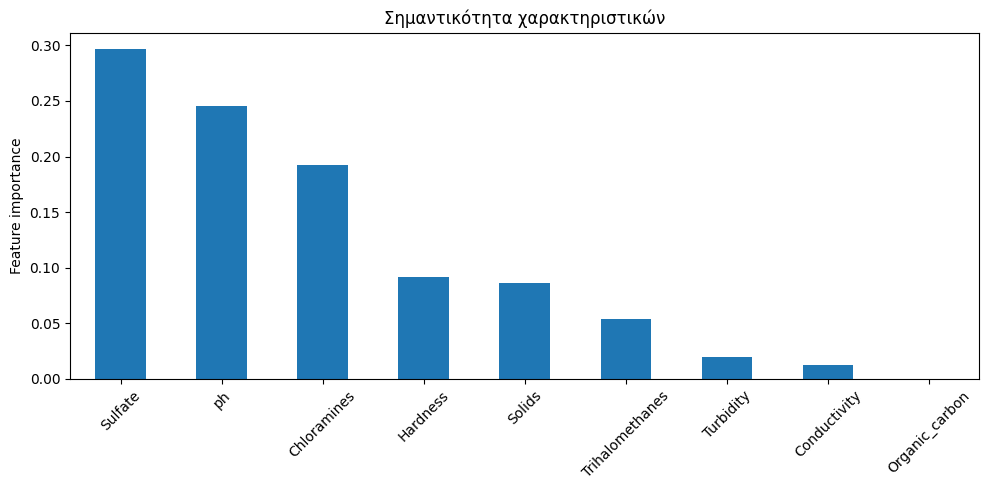

In [34]:
plt.figure(figsize=(10,5))
feature_importances.plot(kind='bar')
plt.title('Σημαντικότητα χαρακτηριστικών')
plt.ylabel('Feature importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Μια συσκευή λοιπόν θα κρατούσε τα 5 πρώτα Sulfate, ph, Chloramines, Hardness, Solids

In [35]:
#λίγο καλύτερα τα πράγματα αλλά όχι πολύ
best_model = None
best_test_acc = -1
best_n = None

for n in [50, 100, 200]:
    rf = RandomForestClassifier(
        n_estimators=n,
        criterion='entropy',
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features=None,
        ccp_alpha=0.0,
        random_state=seed,
        n_jobs=-1,
    )
    rf.fit(x_train, y_train)
    train_acc = rf.score(x_train, y_train)
    test_acc = rf.score(x_test, y_test)

    print(f"n_estimators={n} -> train={train_acc:.3f}, test={test_acc:.3f}")

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_model = rf
        best_n = n

n_estimators=50 -> train=0.697, test=0.663
n_estimators=100 -> train=0.698, test=0.666
n_estimators=200 -> train=0.695, test=0.660


In [36]:
importances = pd.Series(
    best_model.feature_importances_,
    index=input_df.columns
).sort_values(ascending=False)

print(importances)

Sulfate            0.255866
ph                 0.240197
Chloramines        0.125872
Hardness           0.120427
Solids             0.118736
Conductivity       0.045533
Organic_carbon     0.035215
Trihalomethanes    0.030568
Turbidity          0.027587
dtype: float64


In [37]:
top5_features = ['Sulfate', 'ph', 'Chloramines', 'Hardness', 'Solids']


In [38]:
# θα κάνω μια ακόμα προσπάθεια μονο με τα τοπ 5 μήπως πιάσουμε 0.7 accuracy
X = df[top5_features]
y = df['Potability']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=0,
    stratify=y
)

In [39]:
#Πέφτει ελάχιστα το test accuracy αλλά δεν είναι αρκετά καλό έτσι και αλλίως
rf_top5 = RandomForestClassifier(
    n_estimators=100,
    criterion='entropy',
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features=None,
    ccp_alpha=0.0,
    random_state=seed,
    n_jobs=-1
)

rf_top5.fit(X_train, y_train)

train_acc = rf_top5.score(X_train, y_train)
test_acc = rf_top5.score(X_test, y_test)

print(f"Train accuracy: {train_acc:.3f}")
print(f"Test accuracy:  {test_acc:.3f}")

Train accuracy: 0.693
Test accuracy:  0.630


Ίσως φταίει η μικρή ανισορροπία των Κλασεων 0 1 του Potability αλλά δεν είμαι σίγουρός απαντάω τα ερωτήματα 13 14 και θα κάνω μερικές δοκιμές ακόμα.

Tο μη-πόσιμο νερό θέλουμε να προβλέπετε με τεράστια ακρίβεια που πιθανον να ορίζεται και νομικά δια τέτοιες εταιρίες. Επομένως ας χάνουμε μερικές προβλέψεις πόσιμου νερου είναι και πιο ρεαλιστικό γιατί φαντάζομαι πιο συχνα εμφανίζεται πόσιμο νερό παρά μη στόχος είναι η πρόβλεψη των εξαιρέσεων αυτών. Νομίζω το καλύτερο που έχει να κάνει η εταιρεία είναι να προβλέψει το μη πόσιμο το δάσος προφανώς επειδή μειώνει τα varience θεωρείται καλύτερο αλλά ίσως δεν αρκεί στην περιπτωσή μας.

In [40]:
#Το μοντέλο Random Forest ρυθμίστηκε ώστε να δίνει προτεραιότητα στην ανίχνευση μη πόσιμου νερού.
rf = RandomForestClassifier(
    n_estimators=200,
    criterion='entropy',
    max_depth=7,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight={0: 2, 1: 1},
    random_state=0,
    n_jobs=-1
)

rf.fit(X_train, y_train)


y_proba = rf.predict_proba(X_test)[:, 1]
threshold = 0.5
y_pred = (y_proba >= threshold).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")


[[583  17]
 [346  37]]
              precision    recall  f1-score   support

           0      0.628     0.972     0.763       600
           1      0.685     0.097     0.169       383

    accuracy                          0.631       983
   macro avg      0.656     0.534     0.466       983
weighted avg      0.650     0.631     0.531       983

ROC-AUC: 0.656
